# Практическая работа №4: Регуляризация, переобучение и отбор признаков

**Дисциплина:** Машинное обучение (Machine Learning)  
**Студент:** Ли Вадим  
**Группа:** __________________

## Цели занятия

1. Изучить эффект переобучения на примере полиномиальной регрессии.
2. Понять разницу между L1 (Lasso) и L2 (Ridge) регуляризацией.
3. Научиться подбирать гиперпараметры через кросс-валидацию.
4. Проанализировать устойчивость отбора признаков на реальных данных.

## Теоретический блок 1: Bias-Variance Tradeoff и полиномиальная регрессия

Модель машинного обучения стремится минимизировать ошибку обобщения:

$$Error = Bias^2 + Variance + Irreducible\ Error$$

Низкая степень полинома соответствует высокому смещению и недообучению. Высокая степень увеличивает дисперсию и риск переобучения.

Для контроля сложности применяют регуляризацию:

**Ridge (L2):**

$$J(\theta)=MSE(\theta)+\alpha\sum_{j=1}^{n}\theta_j^2$$

**Lasso (L1):**

$$J(\theta)=MSE(\theta)+\alpha\sum_{j=1}^{n}|\theta_j|$$

Ridge уменьшает коэффициенты, но обычно не обнуляет их. Lasso способен занулять коэффициенты и тем самым выполнять отбор признаков.

## Практический блок 1: Генерация данных и кривые обучения

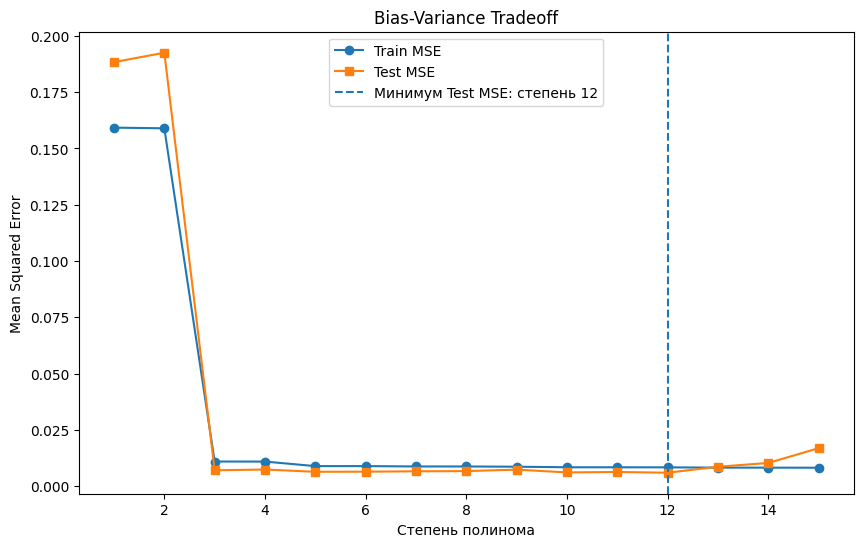

Минимальная Test MSE: 0.005999
Оптимальная степень по тестовой выборке: 12


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

plt.rcParams["figure.figsize"] = (10, 6)

np.random.seed(42)
n_samples = 100
X_syn = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)
y_syn = np.sin(X_syn.ravel()) + np.random.normal(0, 0.1, n_samples)

X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42
)

degrees = range(1, 16)
train_errors = []
test_errors = []

for d in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("lin_reg", LinearRegression())
    ])

    model.fit(X_train_syn, y_train_syn)

    y_train_pred = model.predict(X_train_syn)
    y_test_pred = model.predict(X_test_syn)

    train_errors.append(mean_squared_error(y_train_syn, y_train_pred))
    test_errors.append(mean_squared_error(y_test_syn, y_test_pred))

best_degree = list(degrees)[int(np.argmin(test_errors))]

plt.figure(figsize=(10, 6))
plt.plot(list(degrees), train_errors, label="Train MSE", marker="o")
plt.plot(list(degrees), test_errors, label="Test MSE", marker="s")
plt.axvline(best_degree, linestyle="--", label=f"Минимум Test MSE: степень {best_degree}")
plt.xlabel("Степень полинома")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Tradeoff")
plt.legend()
plt.show()

print(f"Минимальная Test MSE: {min(test_errors):.6f}")
print(f"Оптимальная степень по тестовой выборке: {best_degree}")

### Вывод по блоку 1

При увеличении степени полинома ошибка на обучающей выборке уменьшается. Ошибка на тестовой выборке сначала снижается, а затем начинает расти. Это демонстрирует Bias-Variance Tradeoff: слишком простая модель недообучается, а слишком сложная начинает подстраиваться под шум. Оценивать качество только по Train MSE нельзя.

## Теоретический блок 2: Влияние параметра alpha

При увеличении силы регуляризации:

- Ridge плавно уменьшает коэффициенты.
- Lasso может делать часть коэффициентов точно равными нулю.

Это позволяет Lasso использовать как метод отбора признаков.

## Практический блок 2: Пути регуляризации

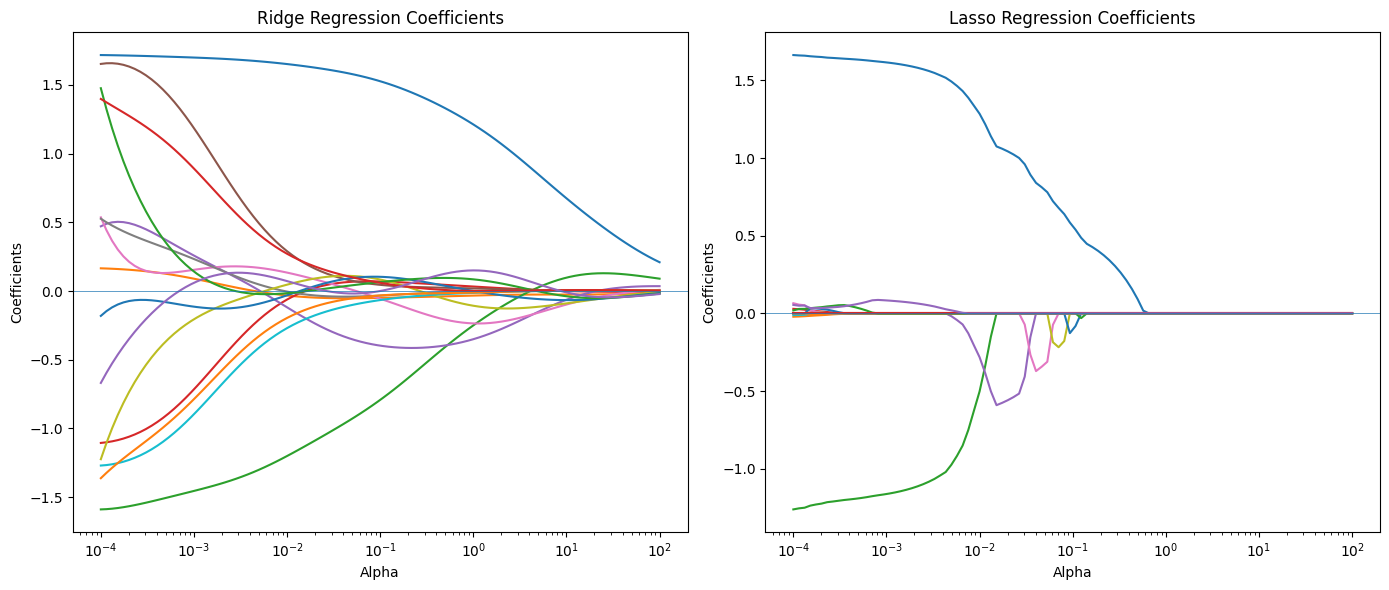

In [2]:
poly = PolynomialFeatures(degree=15, include_bias=False)

X_train_poly = poly.fit_transform(X_train_syn)
X_test_poly = poly.transform(X_test_syn)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

alphas = np.logspace(-4, 2, 100)

ridge_coefs = []
lasso_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train_syn)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train_syn)
    lasso_coefs.append(lasso.coef_)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(alphas, ridge_coefs)
ax[0].set_xscale("log")
ax[0].set_title("Ridge Regression Coefficients")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("Coefficients")
ax[0].axhline(0, linewidth=0.5)

ax[1].plot(alphas, lasso_coefs)
ax[1].set_xscale("log")
ax[1].set_title("Lasso Regression Coefficients")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Coefficients")
ax[1].axhline(0, linewidth=0.5)

plt.tight_layout()
plt.show()

### Вывод по блоку 2

Ridge уменьшает абсолютные значения всех коэффициентов постепенно. Lasso при росте alpha обнуляет часть коэффициентов. Разреженность решения Lasso делает его полезным для интерпретации модели и автоматического отбора признаков.

## Практический блок 3: Автоматический подбор параметров с GridSearchCV

In [3]:
pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("scaler", StandardScaler()),
    ("reg", Ridge())
])

param_grid = {
    "reg": [Ridge(), Lasso(max_iter=10000)],
    "reg__alpha": np.logspace(-4, 2, 20)
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train_syn, y_train_syn)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_syn)

print(f"Лучший CV MSE: {-grid_search.best_score_:.6f}")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Test MSE лучшей модели: {mean_squared_error(y_test_syn, y_pred_best):.6f}")

Лучший CV MSE: 0.010535
Лучшие параметры: {'reg': Ridge(), 'reg__alpha': np.float64(0.0001)}
Test MSE лучшей модели: 0.006416


### Вывод по блоку 3

GridSearchCV подбирает тип регуляризованной модели и значение alpha по кросс-валидации. Это надёжнее ручного выбора параметра по одной тестовой выборке.

## Теоретический блок 3: Реальные данные и мультиколлинеарность

Мультиколлинеарность возникает при сильной корреляции признаков. В обычной линейной регрессии она может делать оценки коэффициентов нестабильными. Ridge-регуляризация уменьшает чувствительность модели к таким зависимостям.

## Практический блок 4: Анализ датасета Diabetes

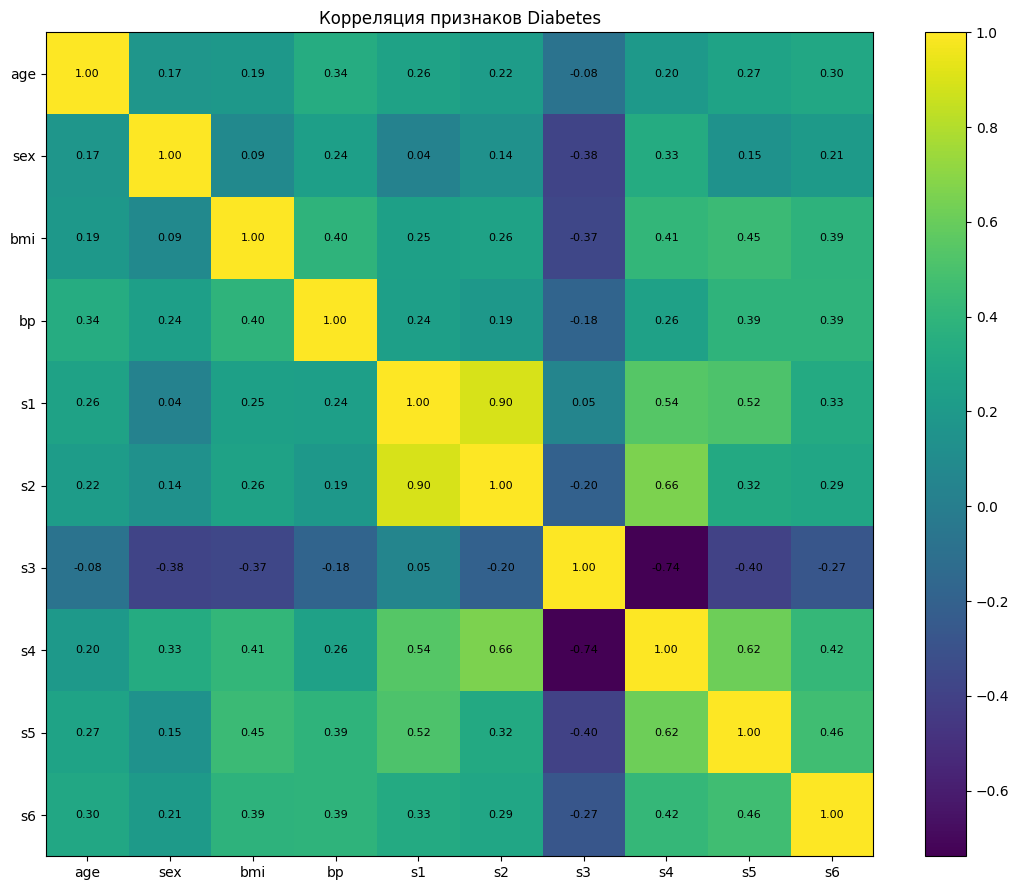

,Model,R²,MSE,Non-Zero Coefs
0,Linear,0.517748,2859.696348,10
1,Ridge,0.517582,2860.682243,10
2,Lasso,0.517376,2861.903917,9


Лучшая модель по R² на полном наборе данных: Linear


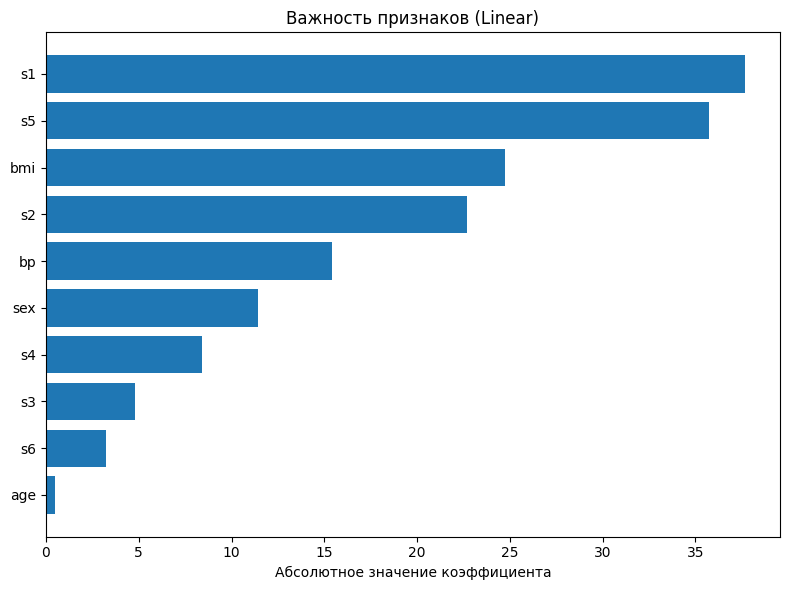

In [4]:
diabetes = load_diabetes()
X_real = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_real = diabetes.target

corr_matrix = X_real.corr()

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(corr_matrix.values, aspect="auto")
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax)
plt.title("Корреляция признаков Diabetes")
plt.tight_layout()
plt.show()

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=10000)
}

results = []

for name, model in models.items():
    pipe_real = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", model)
    ])

    pipe_real.fit(X_real, y_real)
    y_pred = pipe_real.predict(X_real)
    coefs = pipe_real.named_steps["reg"].coef_

    results.append({
        "Model": name,
        "R²": r2_score(y_real, y_pred),
        "MSE": mean_squared_error(y_real, y_pred),
        "Non-Zero Coefs": int(np.sum(np.abs(coefs) > 1e-8))
    })

results_df = pd.DataFrame(results)
display(results_df)

best_model_name = results_df.loc[results_df["R²"].idxmax(), "Model"]
print(f"Лучшая модель по R² на полном наборе данных: {best_model_name}")

best_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", models[best_model_name])
])

best_pipe.fit(X_real, y_real)
coefs = best_pipe.named_steps["reg"].coef_

feat_importance = pd.DataFrame({
    "Feature": X_real.columns,
    "Coefficient": np.abs(coefs)
}).sort_values("Coefficient", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_importance["Feature"], feat_importance["Coefficient"])
plt.xlabel("Абсолютное значение коэффициента")
plt.title(f"Важность признаков ({best_model_name})")
plt.tight_layout()
plt.show()

### Вывод по блоку 4

Корреляционная матрица показывает, что часть признаков Diabetes связана между собой. Линейная модель, Ridge и Lasso дают близкое качество, но регуляризация изменяет структуру коэффициентов. Lasso способен исключать признаки, а Ridge сохраняет все признаки и уменьшает величину их весов.

## Практический блок 5: Устойчивость отбора признаков Lasso

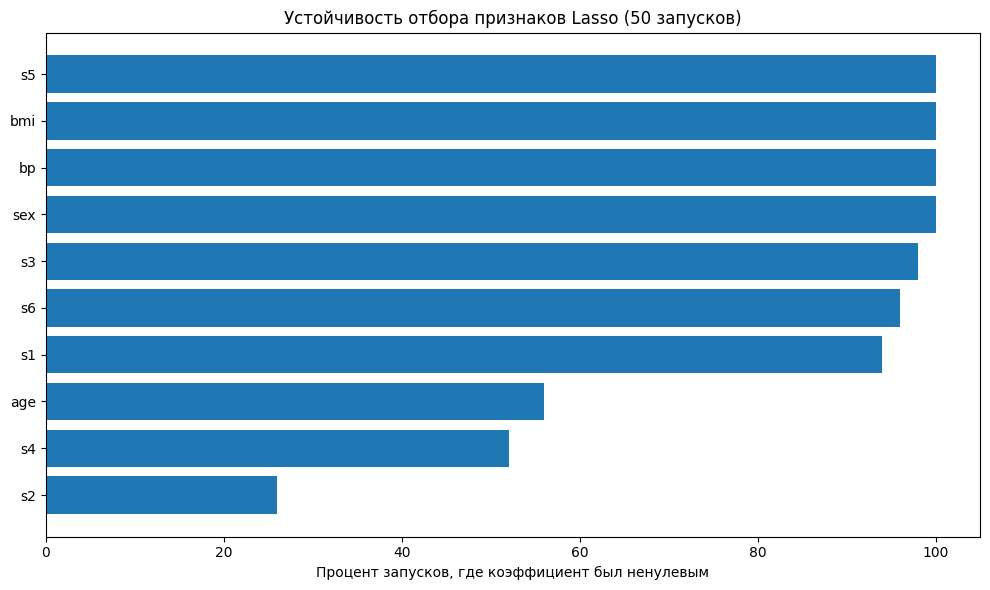

,Feature,Selection_Frequency,Frequency_%
1,sex,50,100.0
2,bmi,50,100.0
8,s5,50,100.0
3,bp,50,100.0
6,s3,49,98.0
9,s6,48,96.0
4,s1,47,94.0
0,age,28,56.0
7,s4,26,52.0
5,s2,13,26.0


Признаки, отобранные более чем в 80% случаев:
['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']


In [5]:
from sklearn.linear_model import LassoCV

n_runs = 50
selected_features_count = {col: 0 for col in X_real.columns}

for i in range(n_runs):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_real,
        y_real,
        test_size=0.2,
        random_state=i
    )

    lasso_cv = LassoCV(cv=5, random_state=i, max_iter=10000)

    pipe_stab = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", lasso_cv)
    ])

    pipe_stab.fit(X_tr, y_tr)
    coefs = pipe_stab.named_steps["reg"].coef_

    for j, col in enumerate(X_real.columns):
        if abs(coefs[j]) > 1e-8:
            selected_features_count[col] += 1

stability_df = pd.DataFrame(
    list(selected_features_count.items()),
    columns=["Feature", "Selection_Frequency"]
)

stability_df["Frequency_%"] = (
    stability_df["Selection_Frequency"] / n_runs
) * 100

stability_sorted = stability_df.sort_values("Frequency_%")

plt.figure(figsize=(10, 6))
plt.barh(stability_sorted["Feature"], stability_sorted["Frequency_%"])
plt.xlabel("Процент запусков, где коэффициент был ненулевым")
plt.title(f"Устойчивость отбора признаков Lasso ({n_runs} запусков)")
plt.tight_layout()
plt.show()

display(stability_df.sort_values("Frequency_%", ascending=False))

stable_features = stability_df.loc[
    stability_df["Frequency_%"] > 80,
    "Feature"
].tolist()

print("Признаки, отобранные более чем в 80% случаев:")
print(stable_features)

### Вывод по блоку 5

Если признак получает ненулевой коэффициент в большинстве разбиений, его можно считать устойчиво выбранным. Признаки с низкой частотой выбора сильнее зависят от конкретной обучающей выборки. Поэтому единичный запуск Lasso не всегда достаточен для окончательного вывода о важности признаков.

# Задания для самостоятельного решения

## Задание 1: Сравнение ElasticNet

Используем ElasticNetCV для подбора `l1_ratio` и `alpha`, затем сравним RMSE и число ненулевых коэффициентов с Ridge и Lasso на датасете Diabetes.

In [6]:
from sklearn.linear_model import RidgeCV, ElasticNetCV

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y_real,
    test_size=0.2,
    random_state=42
)

ridge_alphas = np.logspace(-4, 3, 100)
sparse_alphas = np.logspace(-4, 1, 100)

comparison_models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", RidgeCV(alphas=ridge_alphas, cv=5))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LassoCV(
            alphas=sparse_alphas,
            cv=5,
            max_iter=50000,
            random_state=42
        ))
    ]),
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
            alphas=sparse_alphas,
            cv=5,
            max_iter=50000,
            random_state=42
        ))
    ])
}

comparison_rows = []

for name, model in comparison_models.items():
    model.fit(X_train_real, y_train_real)
    pred = model.predict(X_test_real)
    reg = model.named_steps["reg"]
    coefs = reg.coef_

    row = {
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test_real, pred)),
        "Non-Zero Coefs": int(np.sum(np.abs(coefs) > 1e-8)),
        "Alpha": float(reg.alpha_)
    }

    if name == "ElasticNet":
        row["L1 Ratio"] = float(reg.l1_ratio_)
    else:
        row["L1 Ratio"] = np.nan

    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE")
display(comparison_df)

,Model,RMSE,Non-Zero Coefs,Alpha,L1 Ratio
1,Lasso,52.926738,7,1.555676,NaN
0,Ridge,53.467602,10,38.535286,NaN
2,ElasticNet,53.478380,10,0.107227,0.1


### Вывод по заданию 1

Сравнение выполняется на одной и той же тестовой выборке. Ridge сохраняет все коэффициенты, тогда как Lasso может занулять часть признаков. ElasticNet объединяет L1- и L2-штрафы, а ElasticNetCV подбирает компромисс между ними. Лучшей считается модель с минимальным RMSE в итоговой таблице.

## Задание 2: Влияние объёма данных

Сравним полином 10-й степени с Ridge-регуляризацией и без неё для `N = [20, 50, 100, 500]`.

,N,Linear MSE,Ridge MSE
0,20,165.215431,0.056750
1,50,0.015741,0.030847
2,100,0.001744,0.008748
3,500,0.000215,0.001417


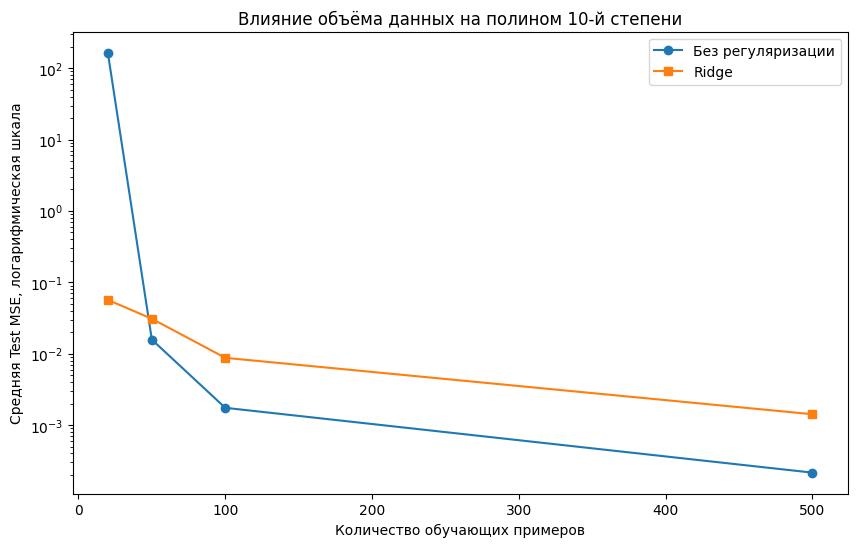

In [7]:
sample_sizes = [20, 50, 100, 500]
repeats = 20

X_eval = np.linspace(-3, 3, 1000).reshape(-1, 1)
y_eval = np.sin(X_eval.ravel())

size_results = []

for n in sample_sizes:
    mse_linear = []
    mse_ridge = []

    for seed in range(repeats):
        rng = np.random.default_rng(seed)

        X_n = rng.uniform(-3, 3, n).reshape(-1, 1)
        y_n = np.sin(X_n.ravel()) + rng.normal(0, 0.1, n)

        model_linear = Pipeline([
            ("poly", PolynomialFeatures(degree=10, include_bias=False)),
            ("scaler", StandardScaler()),
            ("reg", LinearRegression())
        ])

        model_ridge = Pipeline([
            ("poly", PolynomialFeatures(degree=10, include_bias=False)),
            ("scaler", StandardScaler()),
            ("reg", Ridge(alpha=1.0))
        ])

        model_linear.fit(X_n, y_n)
        model_ridge.fit(X_n, y_n)

        mse_linear.append(
            mean_squared_error(y_eval, model_linear.predict(X_eval))
        )

        mse_ridge.append(
            mean_squared_error(y_eval, model_ridge.predict(X_eval))
        )

    size_results.append({
        "N": n,
        "Linear MSE": float(np.mean(mse_linear)),
        "Ridge MSE": float(np.mean(mse_ridge))
    })

size_df = pd.DataFrame(size_results)
display(size_df)

plt.figure(figsize=(10, 6))
plt.plot(size_df["N"], size_df["Linear MSE"], marker="o", label="Без регуляризации")
plt.plot(size_df["N"], size_df["Ridge MSE"], marker="s", label="Ridge")
plt.yscale("log")
plt.xlabel("Количество обучающих примеров")
plt.ylabel("Средняя Test MSE, логарифмическая шкала")
plt.title("Влияние объёма данных на полином 10-й степени")
plt.legend()
plt.show()

### Вывод по заданию 2

При очень малом объёме данных полином 10-й степени без регуляризации имеет высокую дисперсию и может сильно переобучаться. Ridge ограничивает величину коэффициентов и делает такую модель устойчивее. По мере роста обучающей выборки преимущество фиксированной регуляризации уменьшается: данных становится достаточно, а слишком сильный штраф может добавлять смещение.

Регуляризация особенно полезна при малом количестве наблюдений и высокой сложности модели, но её силу необходимо подбирать.

## Задание 3: Анализ остатков

Для лучшей модели из задания 1 строятся график Actual vs Predicted, распределение остатков и Q-Q plot. Нормальность дополнительно проверяется тестом Шапиро-Уилка.

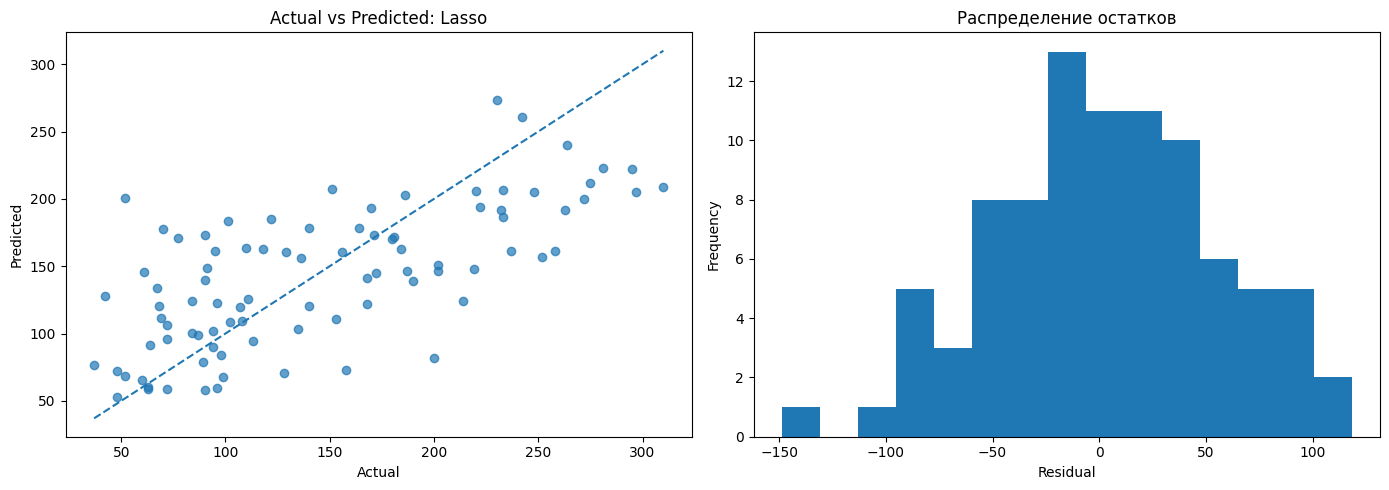

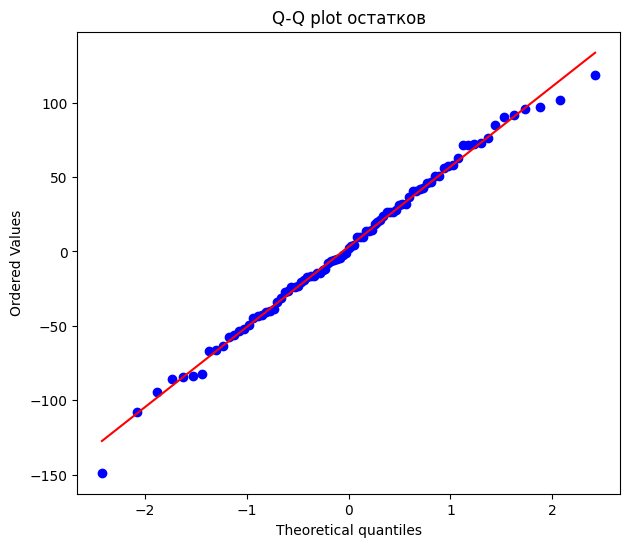

Лучшая модель: Lasso
Shapiro-Wilk statistic: 0.993566
p-value: 0.946048
На уровне значимости 0.05 нет оснований отвергать гипотезу о нормальности остатков.


In [8]:
from scipy import stats

best_name = comparison_df.iloc[0]["Model"]
best_real_model = comparison_models[best_name]

best_real_model.fit(X_train_real, y_train_real)
y_best_pred = best_real_model.predict(X_test_real)
residuals = y_test_real - y_best_pred

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(y_test_real, y_best_pred, alpha=0.7)
line_min = min(np.min(y_test_real), np.min(y_best_pred))
line_max = max(np.max(y_test_real), np.max(y_best_pred))
ax[0].plot([line_min, line_max], [line_min, line_max], linestyle="--")
ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")
ax[0].set_title(f"Actual vs Predicted: {best_name}")

ax[1].hist(residuals, bins=15)
ax[1].set_xlabel("Residual")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Распределение остатков")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot остатков")
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals)

print(f"Лучшая модель: {best_name}")
print(f"Shapiro-Wilk statistic: {shapiro_stat:.6f}")
print(f"p-value: {shapiro_p:.6f}")

if shapiro_p > 0.05:
    print("На уровне значимости 0.05 нет оснований отвергать гипотезу о нормальности остатков.")
else:
    print("На уровне значимости 0.05 гипотеза о нормальности остатков отвергается.")

### Вывод по заданию 3

График Actual vs Predicted показывает, насколько прогнозы близки к идеальной диагонали. Гистограмма и Q-Q plot позволяют визуально оценить форму распределения ошибок, а тест Шапиро-Уилка даёт формальную проверку нормальности.

Если остатки существенно отклоняются от нормального распределения, это может указывать на нелинейность зависимости, выбросы, неодинаковую дисперсию ошибок или пропущенные информативные признаки.

# Итоговый вывод

В работе исследован эффект переобучения полиномиальной регрессии, показано различие между Ridge и Lasso, выполнен автоматический подбор параметров регуляризации и анализ устойчивости отбора признаков.

Ridge уменьшает величину коэффициентов и хорошо подходит при мультиколлинеарности. Lasso способен занулять коэффициенты и выполнять отбор признаков. ElasticNet объединяет свойства L1- и L2-регуляризации. Эксперимент с объёмом данных показывает, что регуляризация особенно важна для сложных моделей при малой выборке. Анализ остатков позволяет дополнительно проверить качество линейной модели.